<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# 🧠 **Redes Neuronales Artificiales (ANN) para Auditores Bancarios**

Este notebook introduce las **redes neuronales artificiales** desde una perspectiva aplicada a la **auditoría bancaria**, donde no basta con maximizar la precisión: también hay que controlar la estabilidad, la trazabilidad, el sesgo, la explicabilidad, el riesgo de sobreajuste y la calidad de los datos.

El objetivo es que un auditor pueda entender qué hace una ANN, cuándo puede ser útil, qué riesgos introduce y cómo validarla correctamente en escenarios como:

- detección de riesgo de auditoría,
- scoring de riesgo de crédito,
- alertas de blanqueo de capitales,
- priorización de operaciones sospechosas,
- segmentación de clientes de riesgo,
- control de modelos complejos usados por áreas de negocio.

## 1. FUNDAMENTOS TEÓRICOS

Una **red neuronal artificial** es un modelo predictivo inspirado de forma muy simplificada en el funcionamiento de neuronas biológicas. En machine learning, una ANN aprende relaciones no lineales entre variables de entrada y una variable objetivo.

En banca, una ANN puede detectar patrones complejos que modelos lineales o árboles simples no capturan fácilmente. Por ejemplo, una operación puede ser sospechosa no solo por su importe, sino por la combinación de importe, país, canal, hora, antigüedad del cliente, historial de reclamaciones y frecuencia reciente de operaciones.

### 1.1 Estructura básica de una ANN

Una red neuronal típica contiene:

| Elemento | Descripción | Lectura para auditoría |
|---|---|---|
| Capa de entrada | Recibe las variables explicativas | Variables bancarias usadas por el modelo |
| Capas ocultas | Transforman la información | Zona de mayor complejidad e interpretabilidad limitada |
| Neuronas | Combinan entradas, pesos y activación | Cada neurona aprende una transformación parcial |
| Pesos | Parámetros aprendidos | Deben validarse indirectamente mediante desempeño, estabilidad y explicabilidad |
| Sesgos/interceptos | Ajustes adicionales | Similar al intercepto de otros modelos, pero por neurona |
| Capa de salida | Produce la predicción | Probabilidad de riesgo de auditoría, default, alerta AML, etc. |

### 1.2 Funcionamiento matemático simplificado

Cada neurona calcula una combinación lineal de las variables de entrada:

$$z = w_1x_1 + w_2x_2 + \cdots + w_px_p + b$$

Después aplica una **función de activación**:

$$a = f(z)$$

La activación permite que el modelo aprenda relaciones **no lineales**. Sin activaciones no lineales, una red neuronal profunda sería equivalente a una transformación lineal más compleja, pero no realmente más potente.

### 1.3 Funciones de activación

| Activación | Uso habitual | Ventajas | Riesgos |
|---|---|---|---|
| ReLU | Capas ocultas | Simple, eficiente, funciona bien | Neuronas muertas si muchos valores quedan en cero |
| Sigmoid | Salida binaria | Produce valores entre 0 y 1 | Saturación y gradientes pequeños |
| Tanh | Capas ocultas antiguas | Centrada en cero | Puede saturarse |
| Softmax | Clasificación multiclase | Probabilidades por clase | Sensible a clases desbalanceadas |

En auditoría bancaria, la salida más frecuente es una **probabilidad**: probabilidad de riesgo de auditoría, probabilidad de impago, probabilidad de alerta relevante, etc.

### 1.4 Entrenamiento: forward pass, loss y backpropagation

El entrenamiento de una ANN se resume en cuatro pasos:

1. **Forward pass**: el modelo calcula predicciones.
2. **Función de pérdida**: se mide el error entre predicción y realidad.
3. **Backpropagation**: se calcula cómo ajustar los pesos para reducir el error.
4. **Optimizador**: se actualizan los pesos, por ejemplo con Adam o SGD.

Para clasificación binaria bancaria se usa habitualmente la **binary cross-entropy**:

$$L = -[y\log(p) + (1-y)\log(1-p)]$$

Donde `p` es la probabilidad predicha de evento: riesgo de auditoría, default, alerta AML positiva, etc.

### 1.5 Hiperparámetros principales

| Hiperparámetro | Significado | Riesgo auditor |
|---|---|---|
| Número de capas | Profundidad de la red | Más complejidad, menos interpretabilidad |
| Neuronas por capa | Capacidad del modelo | Riesgo de sobreajuste |
| Learning rate | Tamaño de actualización | Inestabilidad o aprendizaje lento |
| Epochs | Vueltas completas sobre los datos | Sobreajuste si son demasiadas |
| Batch size | Observaciones por actualización | Puede afectar estabilidad |
| Regularización L1/L2 | Penalización de pesos | Reduce sobreajuste |
| Dropout | Desactiva neuronas aleatoriamente | Mejora generalización, pero complica reproducibilidad |
| Early stopping | Para entrenamiento si no mejora validación | Control clave en auditoría |

### 1.6 Por qué el escalado es obligatorio

Las redes neuronales son muy sensibles a la escala de las variables. Si una variable está en euros y otra en ratios entre 0 y 1, la variable con magnitudes más grandes puede dominar el entrenamiento.

Por eso, antes de entrenar una ANN se debe aplicar normalmente:

- `StandardScaler`, o
- `MinMaxScaler`, o
- transformaciones robustas si hay outliers extremos.

En auditoría, debe quedar documentado **qué escalador se usó, con qué datos se ajustó y cómo se aplicó a nuevos clientes/operaciones**.

### 1.7 ANN en banca: ventajas y limitaciones

| Aspecto | Ventaja | Riesgo |
|---|---|---|
| No linealidad | Captura interacciones complejas | Difícil explicación directa |
| Alto rendimiento | Puede mejorar AUC/recall | Puede optimizar métricas equivocadas |
| Flexibilidad | Sirve para riesgo de auditoría, crédito, AML | Requiere mucha validación |
| Escalabilidad | Funciona con muchos datos | Necesita control de drift |
| Automatización | Reduce carga manual | Riesgo operativo si se usa sin supervisión |

Una ANN no debe aprobarse solo porque tenga buen AUC. En banca se exige una validación más amplia: estabilidad, sensibilidad, fairness, explicabilidad y robustez.

## 2. CASUÍSTICAS CLAVE PARA AUDITORES BANCARIOS

Antes de validar una red neuronal, un auditor debería revisar las siguientes cuestiones.

### 2.1 Desbalanceo de clases

En riesgo de auditoría, AML o default, los eventos positivos suelen ser minoritarios. Una ANN puede obtener alta accuracy prediciendo casi todo como no riesgo de auditoría.

Métricas más relevantes:

- Recall de la clase positiva.
- Precision.
- F1-score.
- ROC-AUC.
- PR-AUC.
- Matriz de confusión.
- Coste esperado de falsos positivos y falsos negativos.

### 2.2 Interpretabilidad y explicabilidad

Las ANN son modelos de caja negra. Por eso, el auditor debe complementar la evaluación con técnicas XAI como:

- importancia por permutación,
- SHAP values,
- Partial Dependence Plots,
- Individual Conditional Expectation,
- análisis de sensibilidad,
- explicación local de casos críticos.

En auditoría bancaria no basta con decir que el modelo predice bien. Hay que poder explicar **qué variables influyen**, **en qué dirección** y **para qué perfiles**.

### 2.3 Riesgo de fuga de información

La fuga de información ocurre cuando el modelo usa variables que no estarían disponibles en el momento real de decisión o que contienen indirectamente la respuesta.

Ejemplos:

- `fecha_recuperacion_deuda` usada para predecir default antes de que ocurra.
- `resultado_investigacion_riesgo de auditoría` usado para detectar riesgo de auditoría.
- `estado_final_expediente` usado como predictor de alerta AML.
- Variables agregadas calculadas usando información futura.

En una ANN, este problema puede pasar desapercibido porque el modelo aprende patrones complejos y no ofrece coeficientes simples.

### 2.4 Drift y estabilidad temporal

Los modelos bancarios se degradan cuando cambia el comportamiento de clientes, comercios, canales o normativa.

Se debe revisar:

- drift de variables de entrada,
- drift de probabilidades predichas,
- variación de métricas por periodo,
- PSI,
- estabilidad de explicaciones SHAP,
- estabilidad por segmento de cliente.

### 2.5 Fairness y sesgo algorítmico

Aunque no se usen variables sensibles explícitas, una ANN puede aprender proxies indirectos.

Variables de riesgo:

- código postal,
- nacionalidad,
- idioma,
- canal de contratación,
- tipo de dispositivo,
- patrones de ingresos,
- sucursal o zona geográfica.

El auditor debe revisar métricas por segmento y justificar diferencias relevantes.

## 3. PREPARACIÓN DEL ENTORNO

In [1]:
# ============================================================
# 1. LIBRERÍAS BÁSICAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [2]:
# ============================================================
# 2. COMPROBACIÓN OPCIONAL DE LIBRERÍAS XAI
# ============================================================

try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible")
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP no está instalado. Puedes instalarlo con: pip install shap")

SHAP disponible


## 4. CARGA DE DATOS DE AUDITORÍA BANCARIA

En esta versión adaptada se utiliza el fichero `auditoria_bancaria_desbalanceada.csv` generado en el script introductorio.

La variable objetivo es `riesgo_auditoria`:

- `0`: operación sin riesgo relevante para auditoría.
- `1`: operación con riesgo o prioridad de revisión.

In [4]:
# ============================================================
# 3. CARGA DEL DATASET DE AUDITORÍA BANCARIA
# ============================================================

ruta_csv = "../../data/auditoria_bancaria_desbalanceada.csv"

try:
    df = pd.read_csv(ruta_csv)
except FileNotFoundError:
    df = pd.read_csv("/mnt/data/auditoria_bancaria_desbalanceada.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (15000, 17)


,id_operacion,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,1,233.39,11739.05,17,3085.27,25.0,763.0,0.309,1,31.0,0.003,oficina,particular,bajo,prestamo,medio,0
1,2,829.72,411.47,15,10457.08,80.0,665.0,0.248,1,37.0,0.007,web,particular,bajo,transferencia,medio,0
2,3,176.14,2928.34,23,5525.19,21.0,610.0,0.257,0,269.0,0.439,cajero,particular,alto,tarjeta,medio,1
3,4,2141.27,3579.99,16,2347.29,71.0,776.0,0.211,0,326.0,0.120,web,pyme,bajo,cuenta,alto,0
4,5,1039.73,1938.84,16,9070.86,27.0,626.0,0.278,0,150.0,0.179,app,particular,bajo,cuenta,bajo,0


In [6]:
print("Dimensiones:", df.shape)
print("Columnas disponibles:")
print(df.columns.tolist())
print("Tasa de riesgo de auditoría:", df["riesgo_auditoria"].mean().round(4))
df.describe(include="all").T

Dimensiones: (15000, 17)
Columnas disponibles:
['id_operacion', 'importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales', 'canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente', 'riesgo_auditoria']
Tasa de riesgo de auditoría: 0.0632


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_operacion,15000.0,NaN,NaN,NaN,7500.5,4330.271354,1.0,3750.75,7500.5,11250.25,15000.0
importe_operacion,15000.0,NaN,NaN,NaN,1459.922872,2694.705284,5.0,333.5425,732.075,1610.82,143318.97
saldo_medio_cliente,15000.0,NaN,NaN,NaN,9824.272609,12503.778828,122.35,3075.8975,5977.365,11731.4875,245519.52
num_operaciones_30d,15000.0,NaN,NaN,NaN,17.932133,4.251047,4.0,15.0,18.0,21.0,36.0
importe_total_30d,15000.0,NaN,NaN,NaN,11404.111911,22673.629097,0.0,2147.5525,5563.94,12193.9825,904093.21
antiguedad_cliente_meses,15000.0,NaN,NaN,NaN,62.7016,33.827017,3.0,38.0,57.0,81.0,292.0
score_crediticio,15000.0,NaN,NaN,NaN,680.3012,85.030305,356.0,623.0,680.0,738.0,900.0
ratio_ingresos_deuda,15000.0,NaN,NaN,NaN,0.285775,0.152676,0.005,0.168,0.266,0.384,0.866
num_alertas_previas,15000.0,NaN,NaN,NaN,0.445,0.661265,0.0,0.0,0.0,1.0,4.0
dias_desde_ultima_revision,15000.0,NaN,NaN,NaN,107.889667,107.334137,1.0,32.0,75.0,151.0,900.0


## 5. ANÁLISIS EXPLORATORIO INICIAL

Antes de entrenar una ANN, el auditor debe revisar:

- distribución de la variable objetivo,
- valores extremos,
- variables con escalas muy diferentes,
- posibles variables de fuga,
- variables sensibles o proxies,
- consistencia temporal si existen fechas.

riesgo_auditoria
0    14052
1      948
Name: count, dtype: int64
Porcentaje:
riesgo_auditoria
0    0.9368
1    0.0632
Name: count, dtype: float64


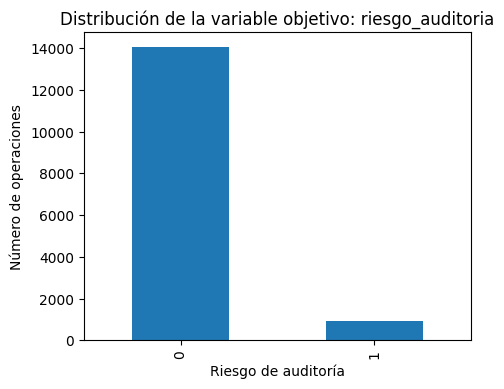

In [7]:
# Distribución de la variable objetivo
conteo = df["riesgo_auditoria"].value_counts().sort_index()
print(conteo)
print("Porcentaje:")
print((conteo / len(df)).round(4))

plt.figure(figsize=(5, 4))
conteo.plot(kind="bar")
plt.title("Distribución de la variable objetivo: riesgo_auditoria")
plt.xlabel("Riesgo de auditoría")
plt.ylabel("Número de operaciones")
plt.show()

In [8]:
# Comparación descriptiva por clase
resumen_clase = df.groupby("riesgo_auditoria").mean(numeric_only=True).T
resumen_clase["diferencia_1_vs_0"] = resumen_clase[1] - resumen_clase[0]
resumen_clase.sort_values("diferencia_1_vs_0", ascending=False)

riesgo_auditoria,0,1,diferencia_1_vs_0
importe_total_30d,10329.139090,27338.202722,17009.063632
importe_operacion,1343.545809,3184.955032,1841.409223
saldo_medio_cliente,9821.310080,9868.185538,46.875458
dias_desde_ultima_revision,107.708796,110.570675,2.861879
num_alertas_previas,0.407273,1.004219,0.596946
porcentaje_operaciones_internacionales,0.125721,0.207286,0.081565
num_operaciones_30d,17.930473,17.956751,0.026279
ratio_ingresos_deuda,0.285182,0.294556,0.009374
antiguedad_cliente_meses,63.725875,47.518987,-16.206888
score_crediticio,683.401153,634.351266,-49.049887


## 6. PARTICIÓN TRAIN / TEST

La partición debe hacerse antes del escalado para evitar contaminación entre entrenamiento y test.

En banca, si el dataset tiene fechas, lo correcto suele ser una partición temporal. Aquí usaremos una partición aleatoria estratificada por simplicidad didáctica.

In [9]:
# ============================================================
# 4. SEPARACIÓN DE VARIABLES Y PREPROCESADO
# ============================================================

TARGET = "riesgo_auditoria"
ID_COLS = ["id_operacion"]

X = df.drop(columns=[TARGET] + ID_COLS, errors="ignore")
y = df[TARGET]

variables_numericas = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
variables_categoricas = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("cat", onehot, variables_categoricas)
    ],
    remainder="drop",
    sparse_threshold=0
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Tasa riesgo train:", y_train.mean().round(4))
print("Tasa riesgo test:", y_test.mean().round(4))

Variables numéricas: ['importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales']
Variables categóricas: ['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente']
Train: (10500, 15) Test: (4500, 15)
Tasa riesgo train: 0.0632
Tasa riesgo test: 0.0631


## 7. MODELO BASE: REGRESIÓN LOGÍSTICA

Antes de aprobar una ANN, conviene compararla con un modelo más simple. Si la ANN mejora muy poco a una regresión logística, puede no justificar su complejidad adicional.

In [11]:
# ============================================================
# 4. MODELO BASE: REGRESIÓN LOGÍSTICA
# ============================================================

modelo_logit = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

modelo_logit.fit(X_train, y_train)
y_prob_logit = modelo_logit.predict_proba(X_test)[:, 1]
y_pred_logit = (y_prob_logit >= 0.5).astype(int)

print("ROC-AUC:", np.round(roc_auc_score(y_test, y_prob_logit), 4))
print("PR-AUC:", np.round(average_precision_score(y_test, y_prob_logit), 4))
print(classification_report(y_test, y_pred_logit))

ROC-AUC: 0.9504
PR-AUC: 0.8593
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      4216
           1       0.45      0.92      0.60       284

    accuracy                           0.92      4500
   macro avg       0.72      0.92      0.78      4500
weighted avg       0.96      0.92      0.94      4500



## 8. PRIMERA RED NEURONAL: MLPClassifier

Usaremos `MLPClassifier` de scikit-learn para evitar dependencias pesadas. Es una red neuronal feedforward básica.

Características del modelo:

- capas densas,
- activación ReLU,
- optimizador Adam,
- salida probabilística para clasificación binaria,
- early stopping para controlar sobreajuste.

In [13]:
# ============================================================
# 5. ANN BÁSICA CON MLPClassifier
# ============================================================

modelo_ann = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=128,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=42
    ))
])

modelo_ann.fit(X_train, y_train)
y_prob_ann = modelo_ann.predict_proba(X_test)[:, 1]
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print("ROC-AUC:", np.round(roc_auc_score(y_test, y_prob_ann), 4))
print("PR-AUC:", np.round(average_precision_score(y_test, y_prob_ann), 4))
print(classification_report(y_test, y_pred_ann))

ROC-AUC: 0.9567
PR-AUC: 0.8932
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4216
           1       0.91      0.81      0.86       284

    accuracy                           0.98      4500
   macro avg       0.95      0.90      0.92      4500
weighted avg       0.98      0.98      0.98      4500



## 9. Función de evaluación reutilizable

Centralizamos las métricas para poder comparar modelos de forma ordenada.

In [14]:
def evaluar_modelo(nombre, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "modelo": nombre,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

resultados = pd.DataFrame([
    evaluar_modelo("Regresión logística", y_test, y_prob_logit),
    evaluar_modelo("ANN básica", y_test, y_prob_ann)
])

resultados.round(4)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regresión logística,0.5,0.9238,0.4491,0.9155,0.6025,0.9504,0.8593
1,ANN básica,0.5,0.9829,0.9091,0.8099,0.8566,0.9567,0.8932


<Figure size 600x500 with 0 Axes>

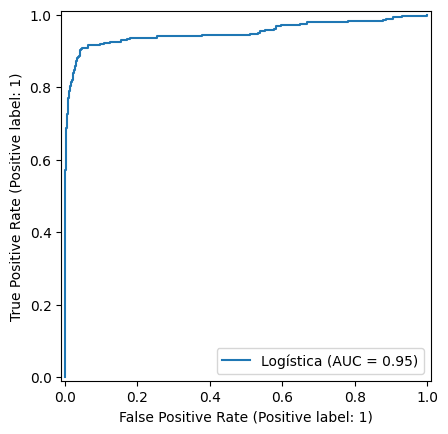

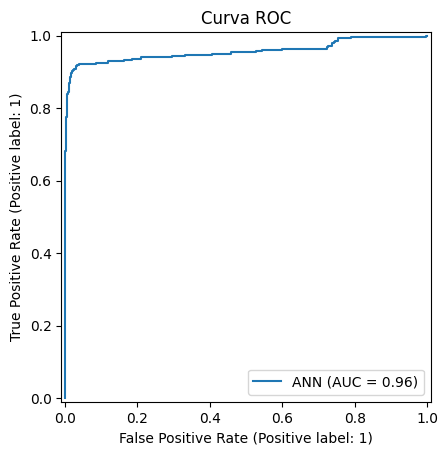

<Figure size 600x500 with 0 Axes>

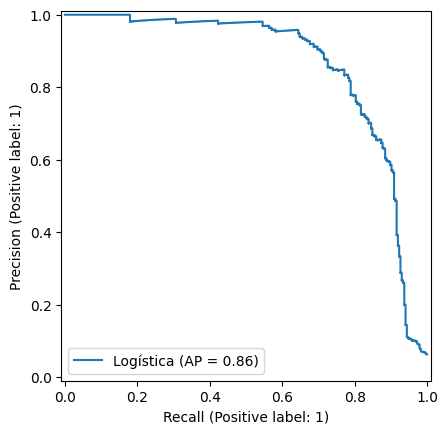

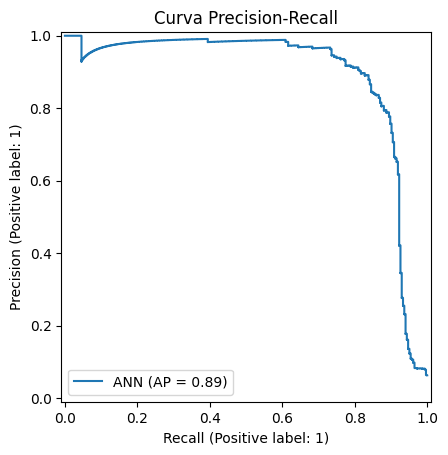

In [15]:
# Curvas ROC y Precision-Recall
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_logit, name="Logística")
RocCurveDisplay.from_predictions(y_test, y_prob_ann, name="ANN")
plt.title("Curva ROC")
plt.show()

plt.figure(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_logit, name="Logística")
PrecisionRecallDisplay.from_predictions(y_test, y_prob_ann, name="ANN")
plt.title("Curva Precision-Recall")
plt.show()

## 10. Matriz de confusión y lectura de negocio

En riesgo de auditoría, un falso negativo puede tener coste económico, reputacional y regulatorio. Un falso positivo también tiene coste: revisión manual, fricción con el cliente y posible bloqueo injustificado.

Por eso, el umbral de decisión no debe fijarse automáticamente en 0.5.

In [16]:
def mostrar_matriz_confusion(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    matriz = pd.DataFrame(
        cm,
        index=["Real 0", "Real 1"],
        columns=["Pred 0", "Pred 1"]
    )
    return matriz

mostrar_matriz_confusion(y_test, y_prob_ann, threshold=0.5)

,Pred 0,Pred 1
Real 0,4193,23
Real 1,54,230


## 11. Selección de umbral según coste

Supongamos:

- falso negativo: operación fraudulenta no detectada → coste 800 €,
- falso positivo: operación normal revisada o bloqueada → coste 25 €.

Buscaremos el umbral que minimiza el coste esperado.

In [17]:
def coste_por_umbral(y_true, y_prob, coste_fp=25, coste_fn=800):
    filas = []
    for threshold in np.linspace(0.01, 0.99, 99):
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        coste = fp * coste_fp + fn * coste_fn
        filas.append({
            "threshold": threshold,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "TN": tn,
            "coste_total": coste,
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "precision": precision_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(filas)

costes_ann = coste_por_umbral(y_test, y_prob_ann)
mejor = costes_ann.loc[costes_ann["coste_total"].idxmin()]
mejor

threshold          0.130000
FP               163.000000
FN                22.000000
TP               262.000000
TN              4053.000000
coste_total    21675.000000
recall             0.922535
precision          0.616471
Name: 12, dtype: float64

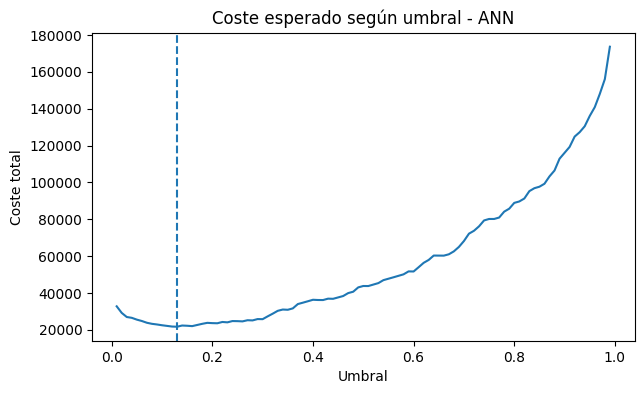

,Pred 0,Pred 1
Real 0,4053,163
Real 1,22,262


In [18]:
plt.figure(figsize=(7, 4))
plt.plot(costes_ann["threshold"], costes_ann["coste_total"])
plt.axvline(mejor["threshold"], linestyle="--")
plt.title("Coste esperado según umbral - ANN")
plt.xlabel("Umbral")
plt.ylabel("Coste total")
plt.show()

mostrar_matriz_confusion(y_test, y_prob_ann, threshold=float(mejor["threshold"]))

## 12. Control del sobreajuste

Una red neuronal puede memorizar patrones del entrenamiento. Señales de sobreajuste:

- desempeño en train mucho mejor que en test,
- pérdida de entrenamiento baja pero validación empeora,
- mucha sensibilidad a pequeñas variaciones,
- explicaciones inestables,
- predicciones extremas injustificadas.

In [19]:
# Comparación train/test

y_prob_train_ann = modelo_ann.predict_proba(X_train)[:, 1]

comparacion_train_test = pd.DataFrame([
    evaluar_modelo("ANN train", y_train, y_prob_train_ann),
    evaluar_modelo("ANN test", y_test, y_prob_ann)
])

comparacion_train_test.round(4)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,ANN train,0.5,0.9913,0.9512,0.9096,0.9299,0.9752,0.9494
1,ANN test,0.5,0.9829,0.9091,0.8099,0.8566,0.9567,0.8932


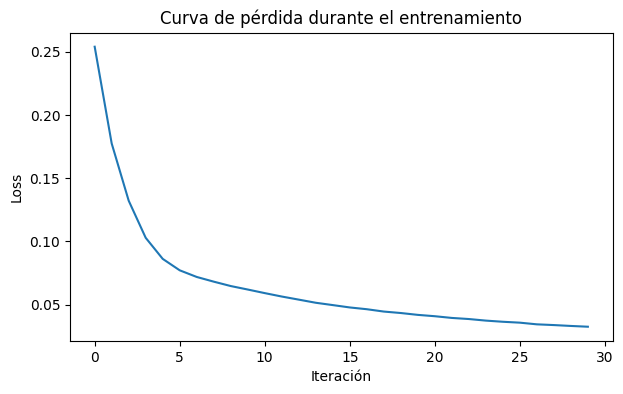

Iteraciones ejecutadas: 30
Early stopping activado: True


In [20]:
# Curva de pérdida del entrenamiento
mlp = modelo_ann.named_steps["model"]

plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_)
plt.title("Curva de pérdida durante el entrenamiento")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.show()

print("Iteraciones ejecutadas:", mlp.n_iter_)
print("Early stopping activado:", mlp.early_stopping)

## 13. Regularización: red pequeña vs red grande

Compararemos una red sencilla con una red más grande. En auditoría, una red más compleja debe justificarse por una mejora clara y estable.

In [21]:
red_pequena = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(8,),
        alpha=0.01,
        max_iter=250,
        early_stopping=True,
        random_state=42
    ))
])

red_grande = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        alpha=0.0001,
        max_iter=250,
        early_stopping=True,
        random_state=42
    ))
])

red_pequena.fit(X_train, y_train)
red_grande.fit(X_train, y_train)

prob_pequena = red_pequena.predict_proba(X_test)[:, 1]
prob_grande = red_grande.predict_proba(X_test)[:, 1]

pd.DataFrame([
    evaluar_modelo("ANN pequeña", y_test, prob_pequena),
    evaluar_modelo("ANN básica", y_test, y_prob_ann),
    evaluar_modelo("ANN grande", y_test, prob_grande)
]).round(4)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,ANN pequeña,0.5,0.9811,0.9462,0.7430,0.8323,0.9545,0.8868
1,ANN básica,0.5,0.9829,0.9091,0.8099,0.8566,0.9567,0.8932
2,ANN grande,0.5,0.9836,0.9234,0.8063,0.8609,0.9551,0.8952


## 14. Búsqueda de hiperparámetros

La optimización debe hacerse con validación cruzada o conjunto de validación. En redes neuronales, la búsqueda puede ser costosa.

Aquí usamos una búsqueda reducida para fines docentes.

In [22]:
# ============================================================
# 6. GRID SEARCH REDUCIDO
# ============================================================

pipe_ann = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        max_iter=250,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    ))
])

param_grid = {
    "model__hidden_layer_sizes": [(16,), (32, 16), (64, 32)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.005]
}

grid = GridSearchCV(
    pipe_ann,
    param_grid=param_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid.best_params_)
print("Mejor PR-AUC CV:", round(grid.best_score_, 4))

Mejores parámetros:
{'model__alpha': 0.01, 'model__hidden_layer_sizes': (16,), 'model__learning_rate_init': 0.005}
Mejor PR-AUC CV: 0.9419


In [23]:
mejor_ann = grid.best_estimator_
y_prob_mejor_ann = mejor_ann.predict_proba(X_test)[:, 1]

pd.DataFrame([
    evaluar_modelo("ANN básica", y_test, y_prob_ann),
    evaluar_modelo("ANN optimizada", y_test, y_prob_mejor_ann)
]).round(4)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,ANN básica,0.5,0.9829,0.9091,0.8099,0.8566,0.9567,0.8932
1,ANN optimizada,0.5,0.9880,0.9675,0.8380,0.8981,0.9563,0.9140


## 15. Comparación con Random Forest

Un auditor debe preguntar: ¿la ANN aporta valor frente a alternativas más interpretables?

Compararemos la ANN con un Random Forest, que suele ser fuerte en datos tabulares.

In [24]:
modelo_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=30,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

modelo_rf.fit(X_train, y_train)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

comparacion_modelos = pd.DataFrame([
    evaluar_modelo("Regresión logística", y_test, y_prob_logit),
    evaluar_modelo("Random Forest", y_test, y_prob_rf),
    evaluar_modelo("ANN optimizada", y_test, y_prob_mejor_ann)
])

comparacion_modelos.round(4)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regresión logística,0.5,0.9238,0.4491,0.9155,0.6025,0.9504,0.8593
1,Random Forest,0.5,0.9033,0.3803,0.8451,0.5246,0.9313,0.6923
2,ANN optimizada,0.5,0.9880,0.9675,0.8380,0.8981,0.9563,0.9140


## 16. Interpretación global: importancia por permutación

La importancia por permutación mide cuánto empeora el modelo cuando se rompe la relación entre una variable y la respuesta.

Ventajas:

- funciona con cualquier modelo,
- es fácil de explicar,
- es útil para modelos de caja negra.

Limitaciones:

- puede verse afectada por variables correlacionadas,
- es más costosa computacionalmente,
- no indica dirección del efecto.

In [25]:
# ============================================================
# 7. IMPORTANCIA POR PERMUTACIÓN
# ============================================================

perm = permutation_importance(
    mejor_ann,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia_media": perm.importances_mean,
    "importancia_std": perm.importances_std
}).sort_values("importancia_media", ascending=False)

importancias

,variable,importancia_media,importancia_std
12,pais_riesgo,0.359576,0.020532
7,num_alertas_previas,0.337283,0.017246
14,segmento_riesgo_cliente,0.312341,0.014252
9,porcentaje_operaciones_internacionales,0.259505,0.010766
5,score_crediticio,0.204914,0.008801
4,antiguedad_cliente_meses,0.204521,0.011006
3,importe_total_30d,0.099296,0.008728
13,producto,0.097914,0.004775
11,tipo_cliente,0.064511,0.006558
10,canal_operacion,0.060693,0.005907


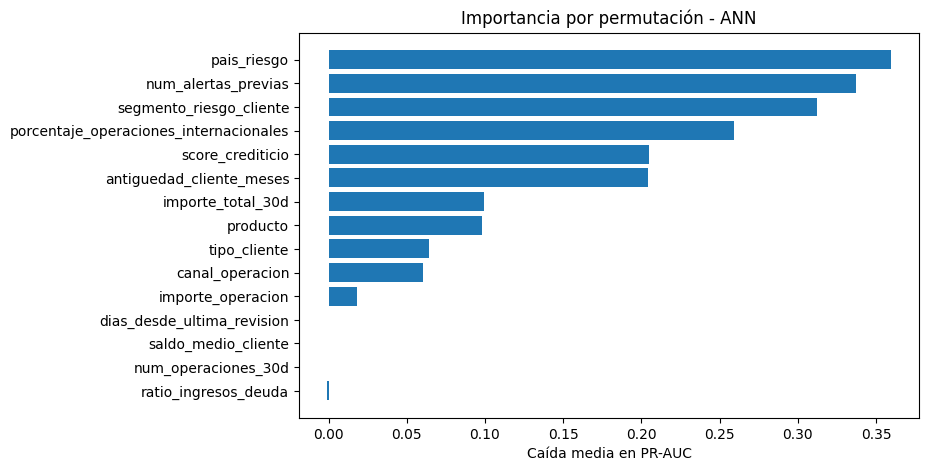

In [26]:
plt.figure(figsize=(8, 5))
plt.barh(importancias["variable"], importancias["importancia_media"])
plt.gca().invert_yaxis()
plt.title("Importancia por permutación - ANN")
plt.xlabel("Caída media en PR-AUC")
plt.show()

## 17. Interpretación parcial: PDP

Los **Partial Dependence Plots** muestran el efecto medio de una variable sobre la predicción manteniendo el resto de variables según su distribución observada.

En una ANN, ayudan a revisar si el comportamiento aprendido es razonable para negocio.

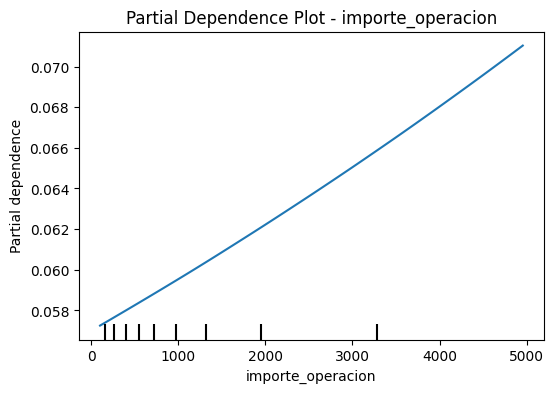

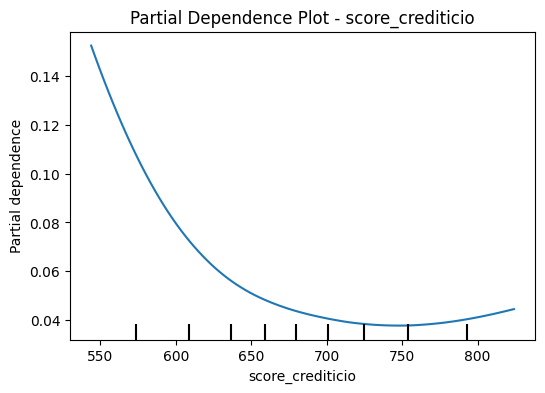

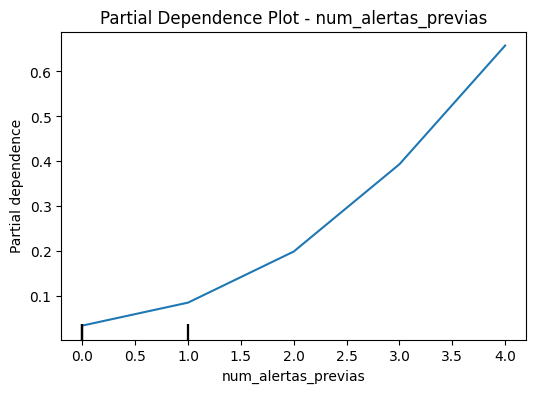

In [27]:
# PDP de variables relevantes del dataset de auditoría
features_pdp = [
    "importe_operacion",
    "score_crediticio",
    "num_alertas_previas"
]

for var in features_pdp:
    if var in X_test.columns:
        fig, ax = plt.subplots(figsize=(6, 4))
        PartialDependenceDisplay.from_estimator(
            mejor_ann,
            X_test,
            features=[var],
            kind="average",
            ax=ax
        )
        plt.title(f"Partial Dependence Plot - {var}")
        plt.show()

## 18. SHAP values para ANN

SHAP permite explicar contribuciones de variables a predicciones concretas.

Para redes neuronales tabulares en scikit-learn, una opción general es `KernelExplainer`, aunque puede ser lento. Por eso usaremos una muestra pequeña.

Lectura auditora:

- SHAP positivo: empuja la predicción hacia mayor riesgo.
- SHAP negativo: empuja la predicción hacia menor riesgo.
- SHAP global: variables más influyentes en promedio.
- SHAP local: explicación de una operación concreta.

In [28]:
# ============================================================
# 8. SHAP OPCIONAL
# ============================================================

if SHAP_AVAILABLE:
    try:
        # Muestra reducida por coste computacional
        X_background = shap.sample(X_train, 50, random_state=42)
        X_explain = shap.sample(X_test, 80, random_state=42)

        def predict_ann(data):
            data_df = pd.DataFrame(data, columns=X.columns)
            return mejor_ann.predict_proba(data_df)[:, 1]

        explainer = shap.KernelExplainer(predict_ann, X_background)
        shap_values = explainer.shap_values(X_explain, nsamples=80)

        print("SHAP calculado correctamente")
    except Exception as e:
        print("No se ha podido calcular SHAP en este entorno:", e)
        shap_values = None
else:
    print("SHAP no disponible. Instala la librería si quieres ejecutar esta sección.")

100%|██████████| 80/80 [00:00<00:00, 128.55it/s]

SHAP calculado correctamente


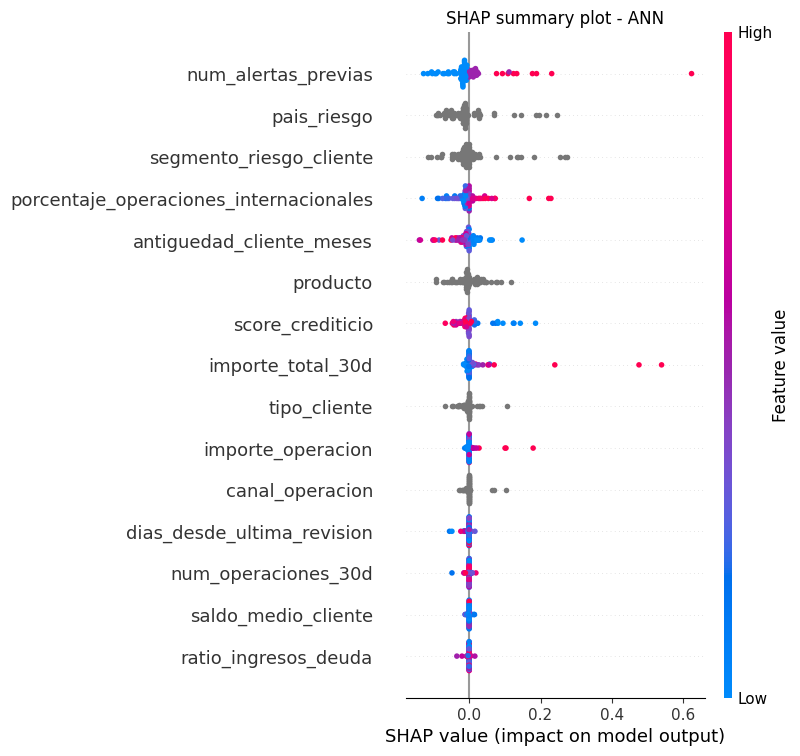

In [29]:
if SHAP_AVAILABLE and "shap_values" in globals() and shap_values is not None:
    shap.summary_plot(shap_values, X_explain, feature_names=X.columns, show=False)
    plt.title("SHAP summary plot - ANN")
    plt.show()

In [ ]:
if SHAP_AVAILABLE and "shap_values" in globals() and shap_values is not None:
    i = 0
    caso = X_explain.iloc[[i]]
    prob_caso = mejor_ann.predict_proba(caso)[:, 1][0]
    print("Probabilidad predicha del caso:", round(prob_caso, 4))
    display(caso)

    shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        caso,
        matplotlib=True,
        show=False
    )
    plt.show()

## 19. Análisis de sensibilidad

El análisis de sensibilidad permite modificar una variable y observar cómo cambia la predicción. Es muy útil para auditoría porque transforma una caja negra en preguntas concretas:

- ¿Qué pasa si aumenta el importe?
- ¿Qué pasa si la operación es nocturna?
- ¿Qué pasa si el cliente es nuevo?
- ¿Qué pasa si sube el score interno de riesgo?

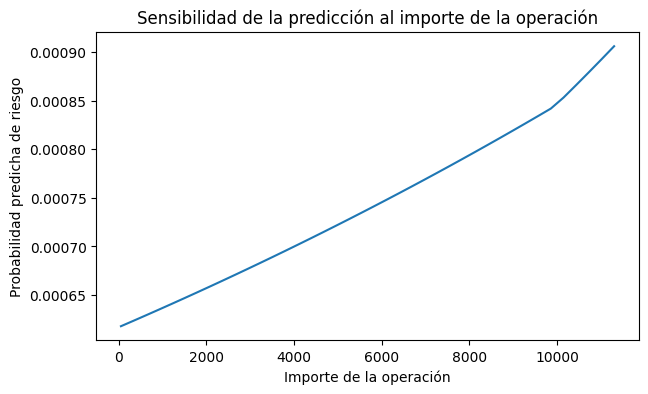

,importe_operacion,probabilidad_predicha
0,48.197300,0.000618
1,336.745333,0.000624
2,625.293367,0.000629
3,913.841400,0.000635
4,1202.389433,0.000641


In [30]:
def sensibilidad_variable(modelo, caso_base, variable, valores):
    filas = []
    for v in valores:
        caso = caso_base.copy()
        caso[variable] = v
        prob = modelo.predict_proba(caso)[0, 1]
        filas.append({variable: v, "probabilidad_predicha": prob})
    return pd.DataFrame(filas)

caso_base = X_test.iloc[[0]].copy()
valores_importe = np.linspace(
    X_train["importe_operacion"].quantile(0.01),
    X_train["importe_operacion"].quantile(0.99),
    40
)

sens_importe = sensibilidad_variable(mejor_ann, caso_base, "importe_operacion", valores_importe)

plt.figure(figsize=(7, 4))
plt.plot(sens_importe["importe_operacion"], sens_importe["probabilidad_predicha"])
plt.title("Sensibilidad de la predicción al importe de la operación")
plt.xlabel("Importe de la operación")
plt.ylabel("Probabilidad predicha de riesgo")
plt.show()

sens_importe.head()

## 20. Segmentación de desempeño

Un modelo puede funcionar bien globalmente y mal en segmentos concretos.

En banca debe revisarse el desempeño por:

- canal,
- edad,
- antigüedad,
- país o región,
- cliente nuevo vs recurrente,
- tipo de producto,
- nivel de renta,
- segmento comercial.

In [31]:
# Evaluación por canal de operación

test_eval = X_test.copy()
test_eval["y_true"] = y_test.values
test_eval["y_prob_ann"] = y_prob_mejor_ann

def metricas_por_segmento(df_eval, segmento):
    filas = []
    for valor, grupo in df_eval.groupby(segmento):
        if grupo["y_true"].nunique() < 2:
            continue
        filas.append({
            segmento: valor,
            "n": len(grupo),
            "tasa_evento": grupo["y_true"].mean(),
            "roc_auc": roc_auc_score(grupo["y_true"], grupo["y_prob_ann"]),
            "pr_auc": average_precision_score(grupo["y_true"], grupo["y_prob_ann"])
        })
    return pd.DataFrame(filas)

metricas_por_segmento(test_eval, "canal_operacion").round(4)

,canal_operacion,n,tasa_evento,roc_auc,pr_auc
0,api,209,0.1340,0.9990,0.9936
1,app,1929,0.0575,0.9561,0.9018
2,cajero,573,0.0663,0.9546,0.9219
3,oficina,555,0.0595,0.9375,0.9080
4,web,1234,0.0600,0.9506,0.9059


In [32]:
# Evaluación por segmento de riesgo del cliente
metricas_por_segmento(test_eval, "segmento_riesgo_cliente").round(4)

,segmento_riesgo_cliente,n,tasa_evento,roc_auc,pr_auc
0,alto,364,0.2253,0.9716,0.9592
1,bajo,2907,0.0361,0.9190,0.8579
2,medio,1229,0.0789,0.9753,0.9374


## 21. PSI para estabilidad de predicciones

El **Population Stability Index** permite comparar distribuciones entre dos muestras. Puede aplicarse a variables o a probabilidades predichas.

Interpretación orientativa:

| PSI | Lectura |
|---|---|
| < 0.10 | Estable |
| 0.10 - 0.25 | Cambio moderado |
| > 0.25 | Cambio relevante |

Debe usarse como señal de alerta, no como criterio único.

In [33]:
def calcular_psi(expected, actual, n_bins=10):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.unique(np.quantile(expected, quantiles))
    bins[0] = -np.inf
    bins[-1] = np.inf

    expected_counts = pd.cut(expected, bins=bins, include_lowest=True).value_counts().sort_index()
    actual_counts = pd.cut(actual, bins=bins, include_lowest=True).value_counts().sort_index()

    expected_perc = expected_counts / expected_counts.sum()
    actual_perc = actual_counts / actual_counts.sum()

    expected_perc = expected_perc.replace(0, 0.0001)
    actual_perc = actual_perc.replace(0, 0.0001)

    psi_values = (actual_perc - expected_perc) * np.log(actual_perc / expected_perc)
    psi_total = psi_values.sum()

    detalle = pd.DataFrame({
        "expected_perc": expected_perc,
        "actual_perc": actual_perc,
        "psi": psi_values
    })

    return psi_total, detalle

# Simulamos un nuevo periodo con operaciones de mayor importe y más actividad internacional
X_nuevo = X_test.copy()
X_nuevo["importe_operacion"] = X_nuevo["importe_operacion"] * 1.25
X_nuevo["porcentaje_operaciones_internacionales"] = np.minimum(
    X_nuevo["porcentaje_operaciones_internacionales"] * 1.5,
    1
)

prob_periodo_base = mejor_ann.predict_proba(X_test)[:, 1]
prob_periodo_nuevo = mejor_ann.predict_proba(X_nuevo)[:, 1]

psi_total, psi_detalle = calcular_psi(prob_periodo_base, prob_periodo_nuevo)
print("PSI total:", round(psi_total, 4))
psi_detalle

PSI total: 0.0281


,expected_perc,actual_perc,psi
"(-inf, 0.000242]",0.1,0.093778,0.000400
"(0.000242, 0.000411]",0.1,0.099333,0.000004
"(0.000411, 0.000599]",0.1,0.088667,0.001363
"(0.000599, 0.000858]",0.1,0.090667,0.000914
"(0.000858, 0.00125]",0.1,0.089111,0.001255
"(0.00125, 0.00191]",0.1,0.090000,0.001054
"(0.00191, 0.0033]",0.1,0.090222,0.001006
"(0.0033, 0.00714]",0.1,0.093333,0.000460
"(0.00714, 0.0673]",0.1,0.116444,0.002504
"(0.0673, inf]",0.1,0.148444,0.019138


## 22. Checklist de auditoría para ANN en banca

Antes de aprobar una ANN, revisar:

1. ¿Existe justificación para usar ANN frente a modelos más simples?
2. ¿Se ha documentado la arquitectura?
3. ¿Se ha documentado el escalado y preprocessing?
4. ¿Se ha controlado el desbalanceo?
5. ¿Se ha usado validación temporal si aplica?
6. ¿Se han comparado métricas train/test?
7. ¿Se ha evaluado el umbral de decisión con costes?
8. ¿Se ha revisado la matriz de confusión?
9. ¿Se ha calculado PR-AUC además de ROC-AUC?
10. ¿Se han revisado segmentos sensibles o proxies?
11. ¿Se han aplicado técnicas XAI?
12. ¿Se han explicado casos individuales de alto impacto?
13. ¿Se ha medido estabilidad temporal?
14. ¿Existe plan de monitorización?
15. ¿Se ha documentado cómo actuar ante drift?

# 23. EJERCICIOS PRÁCTICOS

A continuación se proponen 10 ejercicios con nuevos datos sintéticos. Cada ejercicio está pensado para que el alumnado practique una casuística distinta de auditoría de redes neuronales en banca.

### 📝 EJERCICIO 1: Clasificación de riesgo de auditoría con ANN básica

In [ ]:
# Datos nuevos para el ejercicio 1
np.random.seed(101)
n_ej = 3000
X_ej1 = pd.DataFrame({
    "importe": np.random.lognormal(4.5, 1.1, n_ej),
    "operaciones_24h": np.random.poisson(2.5, n_ej),
    "internacional": np.random.binomial(1, 0.20, n_ej),
    "noche": np.random.binomial(1, 0.25, n_ej),
    "score_cliente": np.random.beta(2, 4, n_ej)
})
logit_ej1 = -4 + 0.0002*X_ej1["importe"] + 0.35*X_ej1["operaciones_24h"] + 1.0*X_ej1["internacional"] + 0.8*X_ej1["noche"] + 2.5*X_ej1["score_cliente"]
y_ej1 = np.random.binomial(1, 1/(1+np.exp(-logit_ej1)))

# Tarea:
# 1. Divide en train/test.
# 2. Entrena una ANN con MLPClassifier.
# 3. Evalúa ROC-AUC, PR-AUC, recall, precision y F1.
# 4. Interpreta si el modelo sería aceptable para detección de fraude.

### 📝 EJERCICIO 2: Comparación contra regresión logística

In [ ]:
# Datos nuevos para el ejercicio 2
np.random.seed(102)
n_ej = 3500
X_ej2 = pd.DataFrame({
    "deuda_ingresos": np.random.beta(2, 5, n_ej),
    "retrasos_previos": np.random.poisson(0.8, n_ej),
    "antiguedad_cliente": np.random.exponential(60, n_ej),
    "uso_tarjeta": np.random.beta(2, 2, n_ej),
    "consultas_bureau": np.random.poisson(1.2, n_ej)
})
logit_ej2 = -3.2 + 3*X_ej2["deuda_ingresos"] + 0.65*X_ej2["retrasos_previos"] - 0.008*X_ej2["antiguedad_cliente"] + 1.4*X_ej2["uso_tarjeta"] + 0.3*X_ej2["consultas_bureau"]
y_ej2 = np.random.binomial(1, 1/(1+np.exp(-logit_ej2)))

# Tarea:
# 1. Entrena una regresión logística y una ANN.
# 2. Compara métricas.
# 3. Decide si la mejora de la ANN justifica su complejidad.

### 📝 EJERCICIO 3: Selección de umbral por coste

In [ ]:
# Usa X_ej1 / y_ej1 del ejercicio 1 o genera un dataset similar.
# Tarea:
# 1. Entrena una ANN.
# 2. Calcula coste esperado con coste_FP = 20 y coste_FN = 1000.
# 3. Encuentra el umbral óptimo.
# 4. Compara la matriz de confusión con umbral 0.5 y con umbral óptimo.

### 📝 EJERCICIO 4: Impacto del escalado

In [ ]:
# Datos nuevos para el ejercicio 4
np.random.seed(104)
n_ej = 2500
X_ej4 = pd.DataFrame({
    "importe_euros": np.random.lognormal(5, 1.2, n_ej),
    "ratio_riesgo": np.random.beta(2, 5, n_ej),
    "num_alertas": np.random.poisson(1.5, n_ej),
    "edad": np.random.normal(45, 12, n_ej)
})
logit_ej4 = -4 + 0.00015*X_ej4["importe_euros"] + 2.7*X_ej4["ratio_riesgo"] + 0.45*X_ej4["num_alertas"] - 0.01*X_ej4["edad"]
y_ej4 = np.random.binomial(1, 1/(1+np.exp(-logit_ej4)))

# Tarea:
# 1. Entrena una ANN sin escalado.
# 2. Entrena una ANN con StandardScaler.
# 3. Compara resultados.
# 4. Explica por qué el escalado es obligatorio.

### 📝 EJERCICIO 5: Red pequeña vs red grande

In [ ]:
# Tarea:
# 1. Crea una red pequeña: hidden_layer_sizes=(8,)
# 2. Crea una red grande: hidden_layer_sizes=(128, 64, 32)
# 3. Compara train vs test.
# 4. Identifica señales de sobreajuste.

### 📝 EJERCICIO 6: Regularización con alpha

In [ ]:
# Tarea:
# 1. Entrena tres ANN con alpha = 0.0001, 0.001 y 0.01.
# 2. Compara ROC-AUC y PR-AUC.
# 3. Analiza si aumenta o reduce el sobreajuste.
# 4. Justifica qué configuración aprobarías como auditor.

### 📝 EJERCICIO 7: Evaluación por segmentos

In [ ]:
# Datos nuevos para el ejercicio 7
np.random.seed(107)
n_ej = 3200
X_ej7 = pd.DataFrame({
    "importe": np.random.lognormal(4.6, 1, n_ej),
    "canal_digital": np.random.binomial(1, 0.70, n_ej),
    "cliente_nuevo": np.random.binomial(1, 0.18, n_ej),
    "score_riesgo": np.random.beta(2, 5, n_ej),
    "operaciones_24h": np.random.poisson(2, n_ej)
})
logit_ej7 = -4.1 + 0.0002*X_ej7["importe"] + 0.7*X_ej7["canal_digital"] + 0.9*X_ej7["cliente_nuevo"] + 2.4*X_ej7["score_riesgo"] + 0.35*X_ej7["operaciones_24h"]
y_ej7 = np.random.binomial(1, 1/(1+np.exp(-logit_ej7)))

# Tarea:
# 1. Entrena una ANN.
# 2. Evalúa métricas separando canal_digital = 0 y canal_digital = 1.
# 3. Evalúa métricas separando cliente_nuevo = 0 y cliente_nuevo = 1.
# 4. Indica si hay segmentos con peor desempeño.

### 📝 EJERCICIO 8: Importancia por permutación

In [ ]:
# Tarea:
# 1. Entrena una ANN con cualquiera de los datasets anteriores.
# 2. Calcula permutation_importance.
# 3. Ordena las variables por importancia.
# 4. Explica qué variables revisaría primero un auditor.

### 📝 EJERCICIO 9: Explicación local con SHAP o sensibilidad

In [ ]:
# Tarea:
# 1. Selecciona una operación de alto riesgo predicha por la ANN.
# 2. Explícala usando SHAP si está disponible.
# 3. Si SHAP no está disponible, realiza análisis de sensibilidad cambiando una variable cada vez.
# 4. Redacta una explicación comprensible para un comité de riesgos.

### 📝 EJERCICIO 10: Informe final de auditoría de una ANN

In [ ]:
# Tarea final:
# Redacta un informe de auditoría que incluya:
# 1. Objetivo del modelo.
# 2. Variables usadas.
# 3. Arquitectura de la ANN.
# 4. Métricas globales.
# 5. Métricas por segmento.
# 6. Análisis de umbral.
# 7. Explicabilidad global y local.
# 8. Riesgos detectados.
# 9. Recomendación: aprobar, aprobar con condiciones o rechazar.
# 10. Plan de monitorización posterior.

## 24. RESUMEN FINAL

Las redes neuronales pueden ser útiles en banca cuando existen relaciones no lineales y grandes volúmenes de datos, pero introducen riesgos importantes de interpretabilidad, sobreajuste y gobernanza.

Para auditores, los puntos críticos son:

- no aprobar una ANN solo por accuracy,
- comparar siempre contra modelos simples,
- revisar PR-AUC y matriz de confusión,
- optimizar umbrales según coste de negocio,
- controlar escalado y preprocessing,
- documentar arquitectura e hiperparámetros,
- aplicar XAI para interpretación global y local,
- validar estabilidad temporal y desempeño por segmentos,
- definir monitorización tras despliegue.

Una ANN bien auditada no es solo un modelo predictivo: es un sistema de decisión que debe ser explicable, estable, trazable y gobernable.